# Sistema 6G – Processamento de Sinais IQ e Pré-Distorção Digital com VARMAX

## Objetivo

Este notebook tem como objetivo:

- Entender como o problema de pré-distorção digital pode ser modelado como séries temporais
- Implementar um modelo VARMAX
- Analisar dados reais de amplificador de potência (PA)
- Avaliar desempenho do modelo

---

## Contexto

Em sistemas de comunicação (5G/6G), o amplificador de potência (PA):

- Amplifica o sinal antes da transmissão
- Introduz **não linearidades**, principalmente próximo da saturação

Essas não linearidades causam:

- Distorção do sinal
- Interferência em canais adjacentes
- Perda de eficiência energética

---

## Solução: Pré-Distorção Digital (DPD)

A ideia é:

1. Modelar o comportamento do PA
2. Aplicar uma distorção inversa no sinal de entrada
3. O PA "corrige" essa distorção → saída linearizada

---

## Por que Séries Temporais?

O PA possui **memória**:

- Efeitos térmicos
- Capacitâncias
- Histerese

Ou seja:

> A saída atual depende de entradas passadas

*Isso caracteriza um problema de **séries temporais***


## Bloco 1 - Importações e Carga de Dados
Células 00 .. 03 - Introdução
### Célula 00 - Instalação explicita da versão específica do xlrd.
*<span style="color:grey">O '!' no Jupyter executa o comando no terminal do sistema operacional, não no Python.</span>*

In [42]:
!pip install xlrd==2.0.1

### Célula 01 - Importações de bibliotecas principais

In [43]:
import pandas as pd                                 # Manipulação de tableas (DataFrames)
import numpy as np                                  # Cálculo numérico vetorial
import matplotlib.pyplot as plt                     # Visualização de gráficos
import seaborn as sns                               # Gráficos estatísticos
from sklearn.linear_model import LinearRegression   # Regressão Linear

### Célula 02 - Ajuste de parâmetros visuais

*<span style="color:grey">A customização de parâmetros visuais se da por meio da biblioteca matplotlib, o padrão e também utilizando o objeto **rcParams** do módulo pylab. Significa "Runtime Configuration Parameters".</span>*

In [44]:
from matplotlib.pylab import rcParams               # Customização de parâmetros visuais
rcParams['figure.figsize'] = 15, 6                  # Width = 15 inches; Height = 6 inches
plt.style.use('dark_background')                    # Estilo de background escuro, para os gráficos

### Célula 03 - Carregamento dos dados iniciais

> Para este projeto de telecomunicações, espera-se por dados IQ que provem de instrumentos de medida que exportam em Excel.


In [45]:
from pathlib import Path                            # Construção de Path
data_file = "dadosIniciais.xlsx"                    # Define o nome do arquivo com o DataFrame em Excel

DATA_PATH = Path.cwd() / data_file                  # Constrói o path absoluto para o arquivo de dados

data = pd.read_excel(DATA_PATH, engine="openpyxl")  # Lê o dataframe com o openpyxl, para arquivos .xlsx
print(f"Shape: {data.shape}")                       # Retorna uma tupla (linhas, colunas)
print(f"NaNs por coluna:\n{data.isna().sum()}")     # Retorna a soma de valores NaNs (faltantes) por coluna
assert data.shape[1] >= 4,\
    "Esperadas pelo menos 4 colunas (Xreal, Ximg, Yreal, Yimg)" # verifica se o DataFrame possui pelo menos 4 colunas.

Shape: (48383, 4)
NaNs por coluna:
 1.137157     0
-0.061341     0
 26.208588    0
-1.858761     0
dtype: int64


### Os sinais **IQ**
 Em telecomunicações, sinais IQ são números complexos no domínio discreto, naturalmente representados como vetores bidimensionais: <br>
 #### <center> $x(t) = I(t) + jQ(t)$</center>
 Em que $I(t)$ é a componente em fase (*In-phase*) e $Q(t)$ é a componente em quadratura (*Quadrature*), de um sinal RF, inseparáveis.

#### O uso de `numpy`
A biblioteca `numpy` é crucial para permitir processar milhares ou milhões de amostras, utilizando **operações vetoriais** rápidas, tais como:
- A potência instantânea do sinal: $P(t) = I(t)^2 + Q(t)^2$
- A conversão para dB: $20 log_{10}(A)$, onde $A$ é magnitude do sinal
- Álgebra matricial para o VARMAX: multiplicação de matrizes $A_1 @ Y$

*Sem NumPy, teria de usar loops Python para cada amostra, que é centenas de vezes mais lento.*

## Bloco 02 - Construção dos DataFrames IQ e Cálculo de Magnitude
Células 04 .. 09 - Significado físico dos dados brutos
### Células 04 e 05 - Verificação do dataset
*<span style="color:grey">Retorna as primeiras linhas do dataset</span>*

In [46]:
from pathlib import Path                            # Construção de Path
df_input  = pd.DataFrame()                          # Constrói um novo DataFrame vazio para o sinal IQ de entrada
df_output = pd.DataFrame()                          # Constrói um novo DataFrame vazio para o sinal IQ de saída

# data.iloc[:,i]:
#   - iloc = "Integer Location" baseado no index
#   - [:]  = seleciona TODAS as linhas
#   - [i]  = seleciona a i-ésima coluna (i-based index)
df_input["Xreal"]  = data.iloc[:, 0]                 # Extrai a parte real do sinal de entrada X            | Coluna 0 -> I de entrada
df_input["Ximg"]   = data.iloc[:, 1]                 # Extrai a parte imaginária do sinal de entrada X (Q)  | Coluna 1 -> Q de entrada
df_output["Yreal"] = data.iloc[:, 2]                 # Extrai a parte real do sinal de saída Y (I)          | Coluna 2 -> I de saída
df_output["Yimg"]  = data.iloc[:, 3]                 # Extrai a parte imaginária do sinal de saída Y (Q)    | Coluna 3 -> Q de Saída

df_concat = (pd.concat([df_input, df_output], axis=1)
             .reset_index(drop=True))                # Concatena os dois DataFrames horizontalmente. @axis=1 especifica direção da concatenação (adiciona coluna)
df_concat.head()                                     # Retorna as 5 primeiras linhas do novo DataFrame

,Xreal,Ximg,Yreal,Yimg
0,1.137499,0.082685,26.244322,1.471061
1,1.117805,0.225745,25.818823,4.754794
2,1.078412,0.365120,24.978243,8.000349
3,1.020086,0.498130,23.716368,11.057279
4,0.944010,0.622210,22.005617,13.972568


In [47]:
# Retorna todas as linhas do DataFrame para possível verificação
df_concat

,Xreal,Ximg,Yreal,Yimg
0,1.137499,0.082685,26.244322,1.471061
1,1.117805,0.225745,25.818823,4.754794
2,1.078412,0.365120,24.978243,8.000349
3,1.020086,0.498130,23.716368,11.057279
4,0.944010,0.622210,22.005617,13.972568
...,...,...,...,...
48378,0.852823,-0.726484,19.257505,-17.156517
48379,0.943207,-0.614669,21.376001,-14.639256
48380,1.018323,-0.492173,23.199469,-11.852586
48381,1.076463,-0.360888,24.612610,-8.843221


### Célula 06 - Magnitude e Conversão em Decibel

##### **Parte 1 - Cálculo de Magnitude**
Para o cálculo da **magnitude** (valor absoluto) de um sinal, onde o mesmo é representado por um número complexo do tipo:<br> <center>$ X = X_{real} + j\:X_{img}$</center> <br> Para tal, pode-se utilizar a norma 2 (euclidiana), dada por:<br> <center>$|X| = \sqrt{X_{real}^2 + X_{img}^2}$ </center>

##### **Parte 2 - Conversão em Decibel (dB)**
Para a conversão da magnitude em decibel, basta utilizar a equação: <br> <center>$dB_{X} = 20 \: log_{10}(|X|)$</center> <br>



In [48]:
# -- Construção do DataFrame
df_mag = pd.DataFrame()                                            # Constrói um novo DataFrame vazio para o cálculo da magnitude
df_mag["MAG_Input"]  =\
    np.sqrt(df_concat["Xreal"]**2 + df_concat["Ximg"]**2)          # Calcula a magnitude do sinal de entrada
df_mag["MAG_Output"] =\
    np.sqrt(df_concat["Yreal"]**2 + df_concat["Yimg"]**2)          # Calcula a magnitude do sinal de saída

# -- Conversão de Magnitude para Decibel (dB)
eps = np.finfo(np.float64).eps                                     #
df_mag["MAG_Input_Decibel"]  = 20 * np.log10(df_mag["MAG_Input"].clip(lower=eps))  # Converte a magnitude do sinal de entrada em decibel
df_mag["MAG_Output_Decibel"] = 20 * np.log10(df_mag["MAG_Output"].clip(lower=eps)) # Converte a magnitude do sinal de saída em decibel


### Curva Característica AM/AM
Uma curva AM/AM descreve a relação entre a amplitude de entrada e a de saída de um dispositivo não linear (e.g. o Amplificador de Potência - PA).

                    Curva Característica AM/AM
    Saída (dB)
        │
        │                        ╭──────── Região de Saturação
        │                   ╭───╯         (a saída para de crescer)
        │              ╭───╯
        │         ╭───╯
        │    ╭───╯        ← Região de Compressão
        │   ╯               (a saída começa a comprimir)
        │  ╱
        │ ╱  ← Região Linear
        │╱     (A saída cresce proporcionalmente a entrada)
        ┼──────────────────────── Saída (dB)

Os motivos de utilizar esta curva são extensivos, tais como: <br>
**1 - Medir a linearidade de um Amplificador**

    Amplificador Ideal (Linear):          Amplificador Real (Não Linear):

    Saída (dB)                        Saída (dB)
        │      ╱                           │            ╭────── Saturado
        │     ╱                            │        ╭──╯
        │    ╱                             │     ╭─╯
        │   ╱  Uma Reta Perfeita           │   ╭╯  Desvia do Ideal
        │  ╱   (ganho constante)           │  ╱
        │ ╱                                │ ╱
        │╱                                 │╱
        ┼──────── Entrada (dB)             ┼──────── Entrada (dB)

    Ganho = Saída/Entrada = Constante     O Ganho diminui à alta potência

**2 - Identificar Regiões de Operação Importantes**

    Saída (dB)
        │
        │  Região 3: SATURAÇÃO
        │  ┌─────────────────────────────────────────────
        │  │  • A saída é constante (não cresce mais)
        │  │  • O amplificador está à potência máxima
        │  │  • Distorção severa no sinal
        │  │
        │  │  Região 2: COMPRESSÃO
        │  │  ┌──────────────────────────────────────────
        │  │  │  • A saída cresce mais devagar que a entrada
        │  │  │  • O ganho começa a cair
        │  │  │  • Início das distorções no sinal
        │  │  │
        │  │  │  Região 1: LINEAR
        │  │  │  ┌───────────────────────────────────────
        │  │  │  │  • A saída cresce proporcionalmente a entrada
        │  │  │  │  • Ganho constante
        │  │  │  │  • Distorção mínima
        │  │  │  │  • Região de operação IDEAL
        ┼──┴──┴──┴──────────────────────── Entrada (dB)

**3 - Definir o Ponto de Compressão de 1 dB (P1dB)**

    Saída (dB)
        │
        │               Real ──→  ╭───────
        │                       ╭──╯
        │                   ╭──╯
        │              ╭───╯
        │          ╭──╯          ← Intervalor de 1 dB aqui = P1dB
        │      ╭──╯    ╱ Ideal (extensão linear)
        │  ╭──╯       ╱
        │ ╱          ╱
        │╱          ╱
        ┼──────────────────────── Entarda (dB)

        P1dB = Nível de potência de entrada no qual a saída real
               fica 1 dB abaixo da saída linear ideal.

        Essa é uma especificação CRUCIAL para amplificadores!



### Célula 07 - Curva Característica AM/AM (Y em função de X)

O gráfico da célula 07 apresenta a **Curva Característica AM/AM** (Amplitude-para-Amplitude) de um Amplificador de Potência (Não Linear). O eixo **X** representa a **potência de entrada** e o eixo **Y**, a **potência de saída**, ambos em dB.

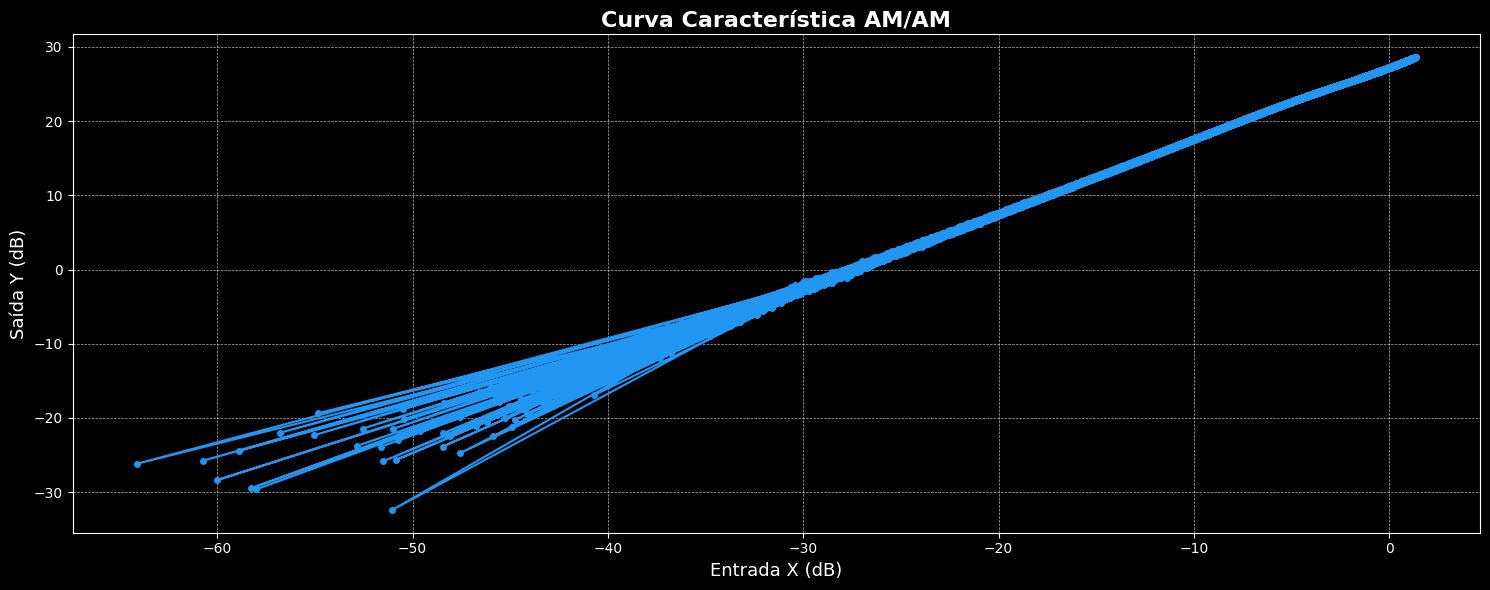

In [49]:
# Plot do gráfico AM/AM para Y x X
#plt.figure(figsize=(10, 6))
plt.plot(df_mag["MAG_Input_Decibel"], df_mag["MAG_Output_Decibel"],
         marker='o', markersize=4, linewidth=1.5, color='#2196F3')
plt.xlabel('Entrada X (dB)', fontsize=13)
plt.ylabel('Saída Y (dB)', fontsize=13)
plt.title('Curva Característica AM/AM', fontsize=16, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Análise da Curva
Ao analisar o gráfico, pode-se concluir que:

**1 - Região de Baixa Potência (Entrada: ~65 dB a -45 dB)**
> Observa-se que existe grande dispersão dos pontos

Os pontos estão muito espalhados nesta região. A saída varia entre -32 dB e -18 dB, para entradas similares, o que indica **alta sensibilidade ao ruído** em sinais de baixa potência. Além disso, o PA tem dificuldades em manter um comportamento consistente com sinais fracos. A relação sinal-ruído (SNR) é baixa nesta faixa, o que explica a dispersão.

**2 - Região de Média Potência (Entrada: -45 dB a -20 dB)**
> Observa-se os pontos começam a convergir

Os dados começam a se alinhar em uma tendência mais definida e a dispersão diminui gradualmente. O comportamento começa a se aproximar de uma relação linear (reta) e o ganho do amplificador está se estabilizando.

**3 - Região de Alta Potência (Entrada: -20 dB a 0 dB)**
> Observa-se que o comportamento é quase perfeitamente linear

Os pontos formar uma linha reta bem definida e a saída vai de aproximadamente +5 dB até +28 dB. O PA opera de forma previsível e consistente, enquanto a dispersão é mínima. Esta é a região ideal de operação do PA.

#### Estimativa do ganho
    Ganho ≈ Saída(dB) - Entrada(dB)

    Na região linear (alta potência):
      Entrada ≈  0 dB  → Saída ≈ +28 dB
      Entrada ≈ -20 dB → Saída ≈ +7 dB

      Ganho ≈ 28 - 0 = 28 dB
      Ganho ≈ 7 - (-20) = 27 dB
    Ganho aproximado do amplificador: ~27-28 dB

<span style="color:grey">A presença de várias linhas paralelas pode indicar: </span>

<span style="color:grey">1. Efeito de memória do amplificador: O comportamento depende não só do sinal atual, mas também de sinais anteriores </span>

<span style="color:grey">2. Múltiplas frequências: Os dados podem conter sinais em diferentes frequências, cada uma com um ganho ligeiramente diferente </span>

<span style="color:grey">3. Variação temporal: Mudanças de temperatura ou condições de operação ao longo do tempo </span>

<span style="color:grey">4. Dados não ordenados: Os pontos estão conectados por linhas na ordem do DataFrame e não por ordem crescente de potência de entrada </span>

### Célula 08 - Ordenação de Dados e Binning

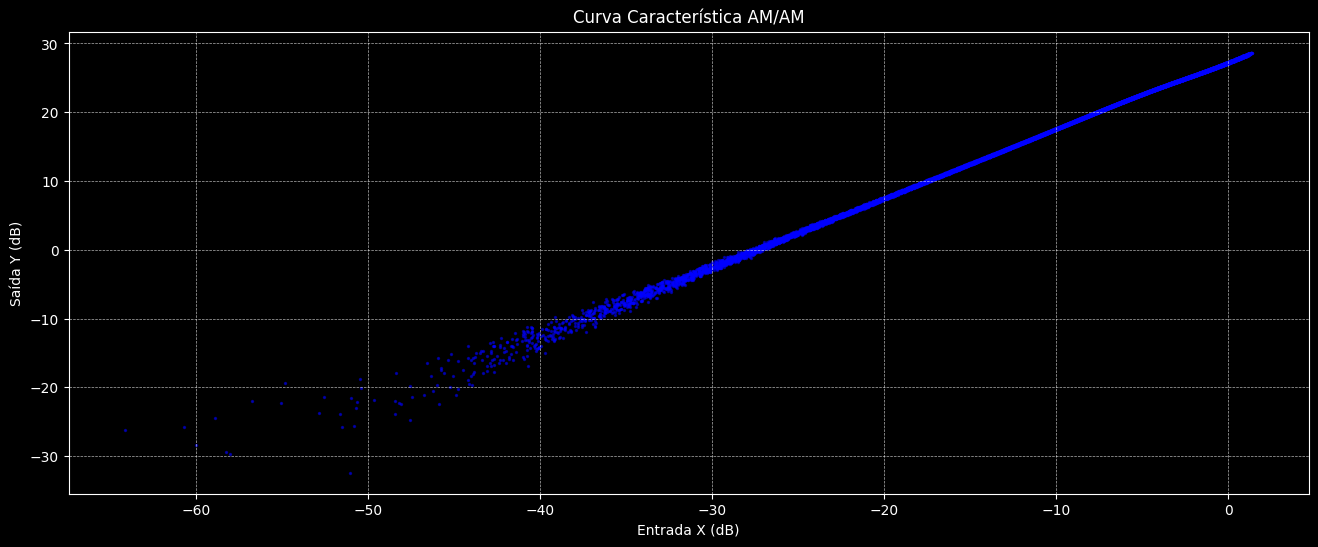

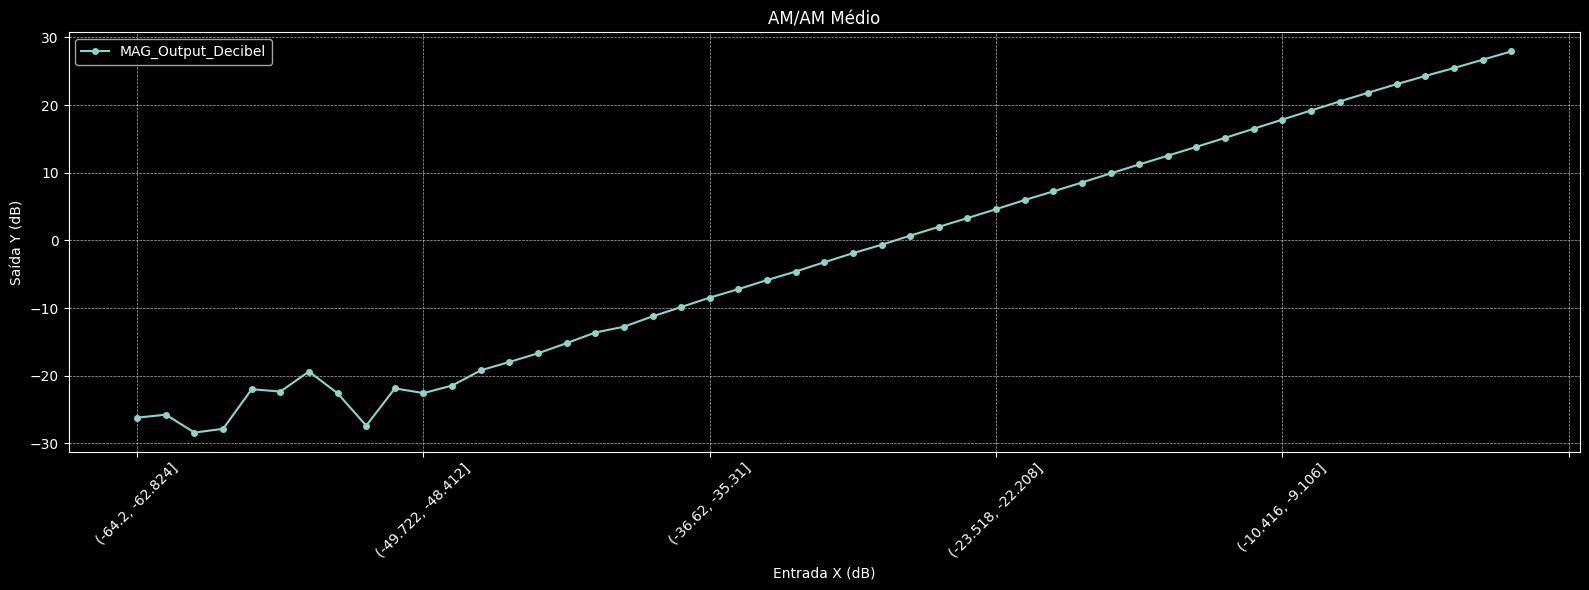

In [50]:
# 1. Ordenar os dados por potência de entrada
df_mag_sorted = df_mag.sort_values("MAG_Input_Decibel")

# 2. Plotar apenas os pontos (sem linhas conectando)
plt.figure(figsize=(16, 6))
plt.scatter(df_mag["MAG_Input_Decibel"],
            df_mag["MAG_Output_Decibel"],
            s=2, alpha=0.5, color='blue')
plt.xlabel("Entrada X (dB)")
plt.ylabel("Saída Y (dB)")
plt.title("Curva Característica AM/AM")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 3. Ou usar média por faixas de potência (binning)
# Criar bins de potência de entrada
df_mag["Input_Bin"] = pd.cut(df_mag["MAG_Input_Decibel"], bins=50)

# Agrupar por bin e calcular a média (sem warning)
df_avg = df_mag.groupby("Input_Bin", observed=True)[["MAG_Output_Decibel"]].mean()

# Plotar a curva AM/AM média
fig, ax = plt.subplots(figsize=(16, 6))
df_avg.plot(ax=ax, title="AM/AM Médio", marker='o', markersize=4, linewidth=1.5)
ax.set_xlabel("Entrada X (dB)")
ax.set_ylabel("Saída Y (dB)")
ax.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Em conclusão
> O gráfico mostra que o amplificador possui um ganho de aproximadamente 27-28 dB e opera de forma linear na região de alta potência. Na região de baixa potência, o ruído domina, causando grande dispersão nos dados. Não se observa compressão de ganho (saturação) na faixa de potência medida, o que sugere que o amplificador está operando abaixo do seu ponto de compressão de 1 dB (P1dB).

### Célula 09 - Análise da Entrada e Saída como Séries Temporais
O objetivo é visualizar como os sinais de Entrada e Saída do PA se comportam ao longo do tempo (amostra por amostra).

Diferente do gráfico AM/AM (que mostra saída vs entrada), aqui quer-se observar cada sinal individualmente, como se fosse uma série temporal, onde:
- Eixo X: Índice da amostra (representa o tempo)
- Eixo Y: Magnitude do sinal em dB

#### Desta maneira, deve ser possível observar nos gráficos:
    1. FORMATO DO SINAL:
       ┌───────────────────────────────────────────────┐
       │ A entrada e a saída têm formatos similares?   │
       │ → SIM: O amplificador está "copiando" o       │
       │        sinal com ganho (comportamento normal) │
       │ → NÃO: Pode haver distorção significativa     │
       └───────────────────────────────────────────────┘

    2. AMPLITUDE (FAIXA DE VALORES):
       ┌───────────────────────────────────────────────┐
       │ Entrada: ex. -65 dB a 0 dB                    │
       │ Saída:   ex. -32 dB a +28 dB                  │
       │ Diferença ≈ Ganho do amplificador             │
       └───────────────────────────────────────────────┘

    3. RUÍDO / DISPERSÃO:
       ┌───────────────────────────────────────────────┐
       │ Variações rápidas e aleatórias indicam ruído  │
       │ Regiões suaves indicam sinal "limpo"          │
       └───────────────────────────────────────────────┘

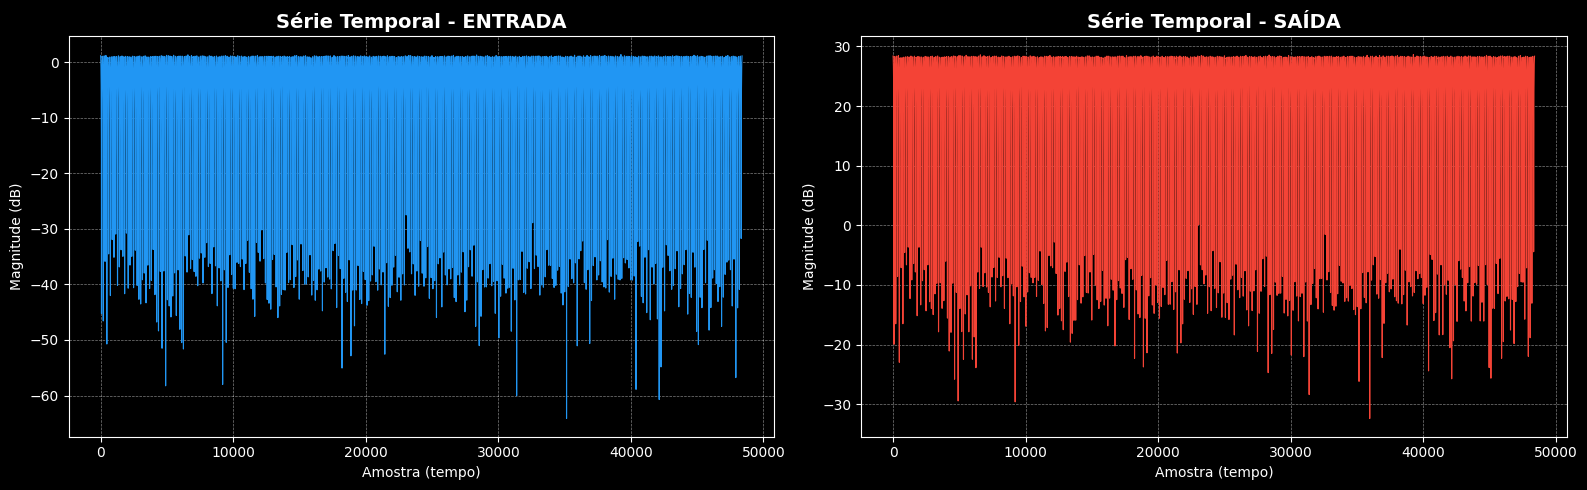

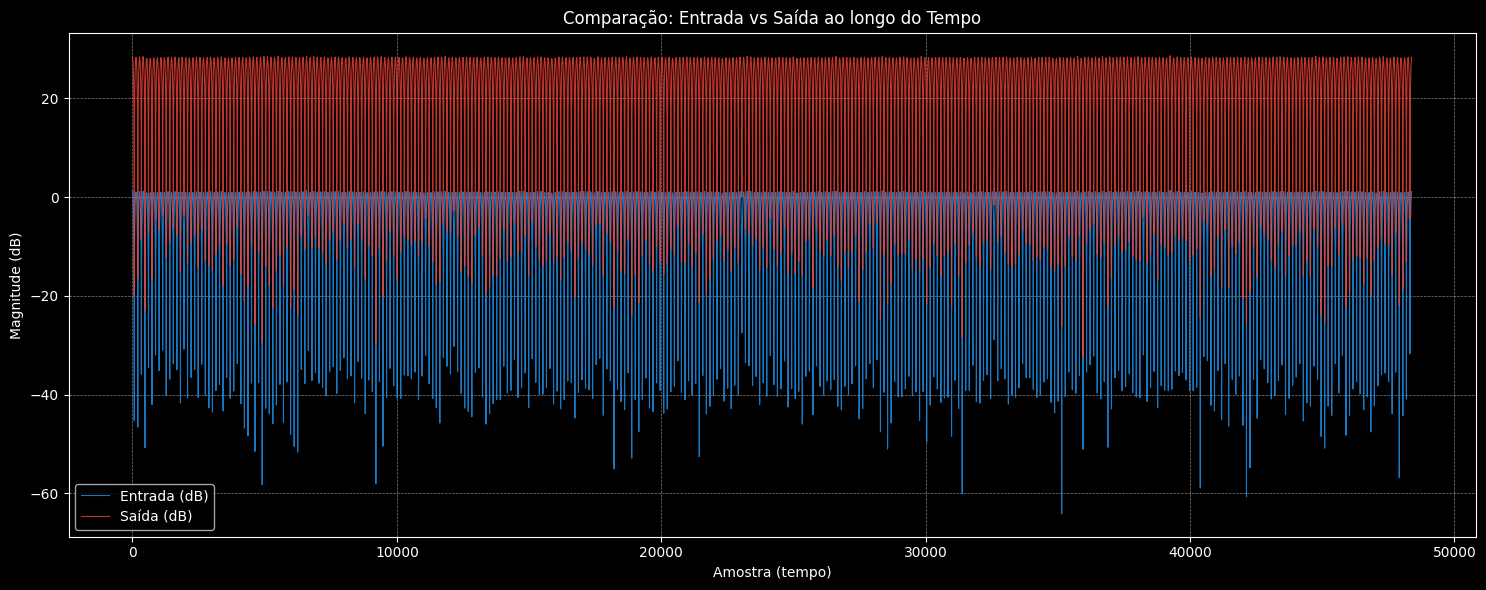

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico da ENTRADA
axes[0].plot(df_mag['MAG_Input_Decibel'].values,
             color='#2196F3', linewidth=0.8)
axes[0].set_title('Série Temporal - ENTRADA', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Amostra (tempo)')
axes[0].set_ylabel('Magnitude (dB)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Gráfico da SAÍDA
axes[1].plot(df_mag['MAG_Output_Decibel'].values,
             color='#f44336', linewidth=0.8)
axes[1].set_title('Série Temporal - SAÍDA', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Amostra (tempo)')
axes[1].set_ylabel('Magnitude (dB)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Ou plotar ambos NO MESMO gráfico para comparação direta
plt.figure(figsize=(15, 6))
plt.plot(df_mag['MAG_Input_Decibel'].values,
         label='Entrada (dB)', color='#2196F3', linewidth=0.8, alpha=0.8)
plt.plot(df_mag['MAG_Output_Decibel'].values,
         label='Saída (dB)', color='#f44336', linewidth=0.8, alpha=0.8)
plt.xlabel('Amostra (tempo)')
plt.ylabel('Magnitude (dB)')
plt.title('Comparação: Entrada vs Saída ao longo do Tempo')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Análise dos Gráficos de Série Temporal

#### Gráfico 01 - Série Temporal devido a <span style="color:#2196F3"> Entrada </span>

    Magnitude (dB)
      +1 │████████████████████████████████████████  ← Picos frequentes (sinal forte)
         │████████████████████████████████████████
     -10 │████████████████████████████████████████
         │
     -30 │█ █ ██ █  █ ██  █  █ █ ██ █  █ █  █ █  ← Região intermediária
         │
     -50 │ █   █    █    █      █    █      █      ← Vales profundos (sinal fraco)
         │
     -65 │  █        █              █              ← Mínimos extremos (ruído?)
         ┼────────────────────────────────────────
         0              Amostras              50000

O sinal de entrada apresenta um comporamento típico de um sinal de comunicação modulado, com picos frequentes próximos de 0 dB (potência alta), vales profundos que caem até -65 db (momentos de baixa potência) e alta razão pico-a-média (PAPR) de aproximadamente 66 dB.

#### Gráfico 02 - Série Temporal devido a <span style="color:#f44336"> Saída </span>

    Magnitude (dB)
     +28 │████████████████████████████████████████  ← Picos frequentes (amplificado)
         │████████████████████████████████████████
     +10 │████████████████████████████████████████
         │
     -10 │█ █ ██ █  █ ██  █  █ █ ██ █  █ █  █ █  ← Região intermediária
         │
     -20 │ █   █    █    █      █    █      █      ← Vales
         │
     -30 │  █        █              █              ← Mínimos
         ┼────────────────────────────────────────
         0              Amostras              50000

A saída é o sinal de entrada amplificado, com formato similar à entrada (o amplificador "copia" o sinal), existe um deslocamento vertical de aproximadamente +27 dB (ganho do PA) e faixa dinâmica comprimida (58 dB vs 66 dB da entrada).

#### Gráfico 03 - Comparação <span style="color:#2196F3"> Entrada </span> vs <span style="color:#f44336"> Saída </span>

    Magnitude (dB)
     +28 │ ██ VERMELHO ██████████████████████████  ← Saída (amplificada)
         │ ████████████████████████████████████████
     +10 │ ████████████████████████████████████████
         │
      +1 │ ██ AZUL ████████████████████████████████ ← Entrada (original)
         │ ████████████████████████████████████████
     -10 │ ████████████████████████████████████████
         │
     -30 │ █ █ AZUL █  █ ██  █  █ █ ██ █  █ █  █  ← Vales da entrada
         │
     -50 │  █   █    █    █      █    █      █     ← Entrada em baixa potência
         │
     -65 │   █        █              █             ← Mínimos da entrada
         ┼────────────────────────────────────────
         0              Amostras              50000

<br><br>

---
| Métrica | Entrada | Saída | Diferença (Ganho/Efeito) |
| :--- | :---: | :---: | :--- |
| **Máximo** | +1 dB | +28 dB | +27 dB (Ganho total) |
| **Mínimo** | -65 dB | -30 dB | +35 dB (Ganho nos mínimos) |
| **Faixa Dinâmica** | **66 dB** | **58 dB** | **-8 dB (Compressão!)** |

Observa-se a confirmação do ganho de ~27-28 dB observado na curva AM/AM.

A faixa dinâmica da Saída (58 dB) é menor que a da entrada (68 dB). Isso indica **compressão** nos sinais de alta potência (os picos estão sendo "achatados").

O PA amplifica mais os sinais fracos do que os sinais fortes, isto indica um comportamento ***não-linear**.

---
O sinal apresenta alta variação de amplitude, com picos frequentes de alta potência e vales profundos esporádicos (*PAPR - Peak-to-Average Power Ratio*). Isso é típíco em sinais de comunicação modernos OFDM como o 5G/6G e QAM.

Esses sinais são conhecidos por seu alto PAPR, o que representa um desafio para PAs, uma vez que eles precisam operar em uma faixa ampla de potências de entrada.


## Bloco 03 - Análise Estatística: Normalidade e Estacionaridade

Para diagnósticos estatísticos é necessário compreender a natureza matemática de séries temporais.

Assim, o bloco segue três sub-etapas com lógica encadeada:

    Histogramas → Teste Shapiro + adicionais  → Testes KPSS + Dickey-Fuller
    (visual)       (normalidade)                    (estacionaridade)

---
### Célula 10 - Análise da Distribuição dos Sinais (Histogramas Individuais)

O objetivo é visualizar a distribuição estatística das partes Real e Imaginária dos sinais de Entrada e Saída do PA, através de histogramas individuais.

Diferente da série temporal (que mostra a evolução no tempo), aqui quer-se observar como os valores se distribuem, ou seja, quais valores ocorrem com mais ou menos frequência.

- Eixo X: Valor da amplitude do sinal (parte Real ou Imaginária)
- Eixo Y: Frequência de ocorrência (quantas vezes cada valor aparece)

#### Desta maneira, deve ser possível observar nos gráficos:

    1. FORMATO DA DISTRIBUIÇÃO:
       ┌───────────────────────────────────────────────────┐
       │ A distribuição tem formato de sino (Gaussiana)?   │
       │ → SIM: Sinal típico de comunicação (OFDM, QAM)    │
       │        Comportamento estatisticamente previsível  │
       │ → NÃO: Pode indicar distorção, ceifamento         │
       │        (clipping) ou saturação do amplificador    │
       └───────────────────────────────────────────────────┘

    2. CENTRALIZAÇÃO (MÉDIA):
       ┌───────────────────────────────────────────────────┐
       │ A distribuição está centrada em zero?             │
       │ → SIM: Sinal sem componente DC (offset)           │
       │        Comportamento esperado para sinais RF      │
       │ → NÃO: Pode indicar um offset DC indesejado       │
       │        ou erro de medição/calibração              │
       └───────────────────────────────────────────────────┘

    3. LARGURA (DESVIO PADRÃO):
       ┌───────────────────────────────────────────────────┐
       │ Comparar a largura entre Entrada e Saída:         │
       │ → Saída MAIS LARGA: O amplificador está           │
       │   aumentando a amplitude (ganho aplicado)         │
       │ → Saída MAIS ESTREITA: Possível compressão        │
       │   ou atenuação do sinal                           │
       └───────────────────────────────────────────────────┘

    4. SIMETRIA:
       ┌───────────────────────────────────────────────────┐
       │ A distribuição é simétrica em torno de zero?      │
       │ → SIM: Sinal balanceado, sem distorção ímpar      │
       │ → NÃO: Pode indicar distorção não-linear          │
       │        ou assimetria no circuito do amplificador  │
       └───────────────────────────────────────────────────┘

In [ ]:
def plot_histograms_dark(df_input, df_output, bins=1000):

    plt.style.use('dark_background')

    config = [
        {"data": df_input["Xreal"],  "title": "Entrada Real (Xreal)",      "color": "#2196F3", "edge": "#0D47A1"},  # Azul Escuro
        {"data": df_input["Ximg"],   "title": "Entrada Imaginária (Ximg)", "color": "#64B5F6", "edge": "#1565C0"},  # Azul Médio
        {"data": df_output["Yreal"], "title": "Saída Real (Yreal)",        "color": "#f44336", "edge": "#B71C1C"},  # Vermelho Escuro
        {"data": df_output["Yimg"],  "title": "Saída Imaginária (Yimg)",   "color": "#FF8A80", "edge": "#C62828"},  # Vermelho Médio
    ]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    for ax, cfg in zip(axes, config):
        ax.hist(cfg["data"], bins=bins,
                edgecolor=cfg["edge"],    # Cor da borda personalizada
                color=cfg["color"], alpha=0.85)
        ax.set_title(f'Histograma - {cfg["title"]}',
                     fontsize=14, fontweight='bold', color='white')
        ax.set_xlabel('Valor', color='white', fontsize=12)
        ax.set_ylabel('Frequência', color='white', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.2, color='gray')

        mean = cfg["data"].mean()
        std = cfg["data"].std()
        ax.axvline(mean, color='#FFFFFF', linestyle='--', linewidth=1.5,
                   label=f'Média: {mean:.4f}')
        ax.axvline(mean + std, color='#AAAAAA', linestyle=':', linewidth=1,
                   label=f'Std: ±{std:.4f}')
        ax.axvline(mean - std, color='#AAAAAA', linestyle=':', linewidth=1)
        ax.legend(fontsize=10, facecolor='black', edgecolor='white',
                  labelcolor='white')

    plt.suptitle('Distribuição dos Sinais de Entrada e Saída',
                 fontsize=18, fontweight='bold', color='white', y=1.02)
    plt.tight_layout()
    plt.show()

plot_histograms_dark(df_input, df_output, bins=1000)

### Célula 11 - Comparação das Distribuições: Entrada vs Saída (Histogramas Sobrepostos)

O objetivo é comparar diretamente as distribuições dos sinais de Entrada e Saída do PA, sobrepondo os histogramas no mesmo gráfico, separados em Parte Real e Parte Imaginária.

Diferente dos histogramas individuais (que analisam cada sinal isoladamente), aqui quer-se observar como o amplificador altera a distribuição do sinal, visualizando entrada e saída simultaneamente.

- Eixo X: Valor da amplitude do sinal (parte Real ou Imaginária)
- Eixo Y: Frequência de ocorrência
- Azul: Sinal de Entrada
- Vermelho: Sinal de Saída

#### Desta maneira, deve ser possível observar nos gráficos:

    1. EXPANSÃO DA DISTRIBUIÇÃO (GANHO):
       ┌───────────────────────────────────────────────────┐
       │ A distribuição vermelha (saída) é mais larga      │
       │ que a azul (entrada)?                             │
       │ → SIM: O amplificador está aplicando GANHO,       │
       │        aumentando a amplitude do sinal            │
       │ → A razão entre as larguras é proporcional        │
       │   ao ganho linear do amplificador                 │
       └───────────────────────────────────────────────────┘

    2. DEFORMAÇÃO DA DISTRIBUIÇÃO (NÃO-LINEARIDADE):
       ┌───────────────────────────────────────────────────┐
       │ A saída mantém o mesmo FORMATO da entrada?        │
       │ → SIM: Amplificador operando na região LINEAR     │
       │        (distribuição apenas "esticada")           │
       │ → NÃO: Indica distorção NÃO-LINEAR                │
       │   • Picos achatados → Compressão/Saturação        │
       │   • Caudas cortadas → Ceifamento (clipping)       │
       │   • Formato diferente → Distorção harmônica       │
       └───────────────────────────────────────────────────┘

    3. REGIÃO DE SOBREPOSIÇÃO (OVERLAP):
       ┌───────────────────────────────────────────────────┐
       │ A região ROXA (sobreposição azul + vermelho)      │
       │ indica onde os valores de entrada e saída         │
       │ coincidem.                                        │
       │ → Pouca sobreposição: Alto ganho (grande          │
       │   diferença entre entrada e saída)                │
       │ → Muita sobreposição: Baixo ganho ou              │
       │   faixas de operação similares                    │
       └───────────────────────────────────────────────────┘

    4. ESTATÍSTICAS (MÉDIA E DESVIO PADRÃO):
       ┌───────────────────────────────────────────────────┐
       │ As linhas tracejadas mostram a MÉDIA de cada      │
       │ distribuição e as linhas pontilhadas mostram      │
       │ o DESVIO PADRÃO (±1σ).                            │
       │                                                   │
       │ → Médias próximas de zero: Sem offset DC          │
       │ → Desvio padrão da saída > entrada: Ganho         │
       │ → Razão dos desvios ≈ Ganho linear em escala      │
       │   de amplitude                                    │
       └───────────────────────────────────────────────────┘

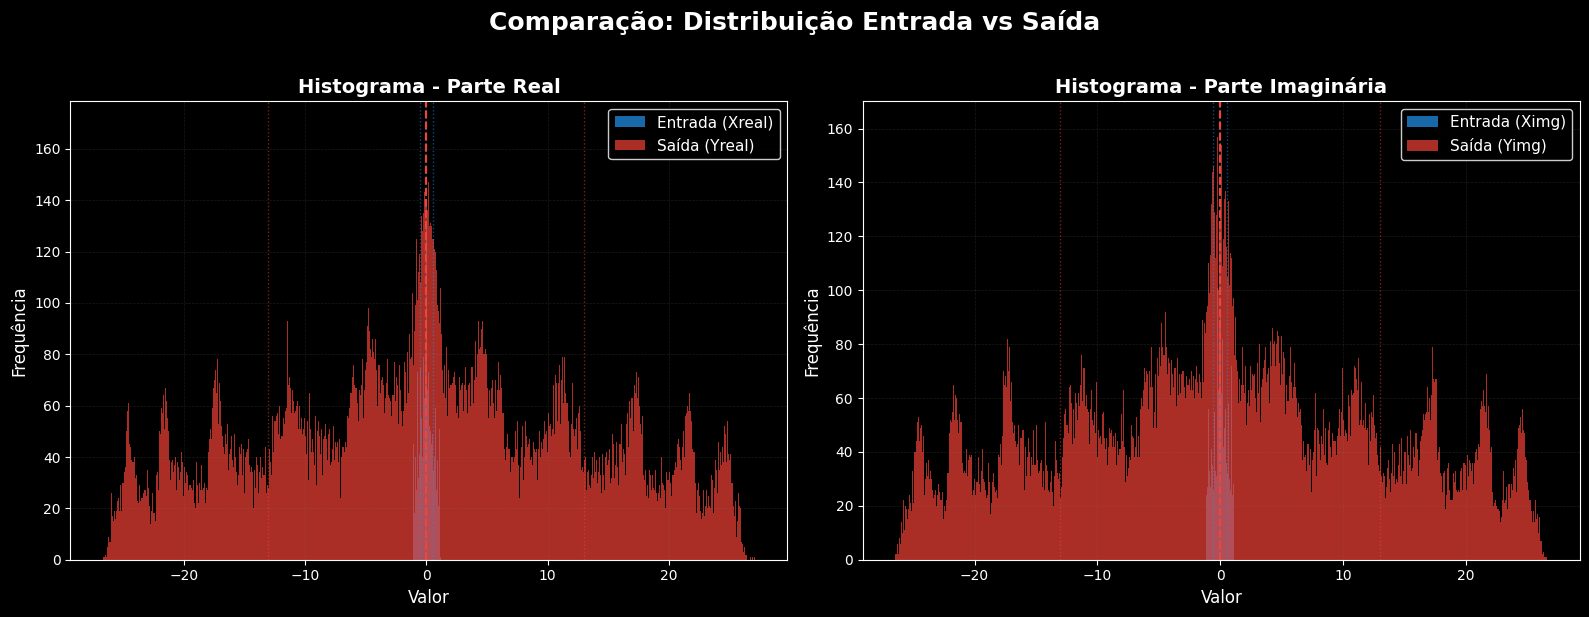

In [68]:
def plot_histogram_comparison(df_input, df_output, bins=1000,
                               dark_mode=True, figsize=(16, 6),
                               input_color='#2196F3', output_color='#f44336',
                               alpha=0.7, show_stats=True):
    """
    Plota histogramas sobrepostos comparando Entrada vs Saída
    para as partes Real e Imaginária dos sinais.

    Parameters:
    -----------
    df_input     : pd.DataFrame  -> DataFrame com colunas 'Xreal' e 'Ximg'
    df_output    : pd.DataFrame  -> DataFrame com colunas 'Yreal' e 'Yimg'
    bins         : int           -> Número de intervalos do histograma
    dark_mode    : bool          -> Ativar fundo preto (True/False)
    figsize      : tuple         -> Tamanho da figura (largura, altura)
    input_color  : str           -> Cor dos histogramas de entrada
    output_color : str           -> Cor dos histogramas de saída
    alpha        : float         -> Transparência (0 a 1)
    show_stats   : bool          -> Mostrar linhas de média e desvio padrão
    """

    # ============================================================
    # Configuração do estilo
    # ============================================================
    if dark_mode:
        plt.style.use('dark_background')
        text_color = 'white'
        grid_color = 'gray'
        legend_face = 'black'
        legend_edge = 'white'
    else:
        plt.style.use('default')
        text_color = 'black'
        grid_color = 'lightgray'
        legend_face = 'white'
        legend_edge = 'black'

    # ============================================================
    # Configuração dos gráficos
    # ============================================================
    config = [
        {
            "title": "Histograma - Parte Real",
            "input":  {"data": df_input["Xreal"],  "label": "Entrada (Xreal)"},
            "output": {"data": df_output["Yreal"], "label": "Saída (Yreal)"},
        },
        {
            "title": "Histograma - Parte Imaginária",
            "input":  {"data": df_input["Ximg"],  "label": "Entrada (Ximg)"},
            "output": {"data": df_output["Yimg"], "label": "Saída (Yimg)"},
        },
    ]

    # ============================================================
    # Plotagem
    # ============================================================
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    for ax, cfg in zip(axes, config):

        # Histograma da ENTRADA
        ax.hist(cfg["input"]["data"], bins=bins, edgecolor='none',
                color=input_color, alpha=alpha, label=cfg["input"]["label"])

        # Histograma da SAÍDA
        ax.hist(cfg["output"]["data"], bins=bins, edgecolor='none',
                color=output_color, alpha=alpha, label=cfg["output"]["label"])

        # Estatísticas (média e desvio padrão)
        if show_stats:
            for data, color in [(cfg["input"]["data"], input_color),
                                (cfg["output"]["data"], output_color)]:
                mean = data.mean()
                std = data.std()
                ax.axvline(mean, color=color, linestyle='--', linewidth=1.5)
                ax.axvline(mean + std, color=color, linestyle=':', linewidth=1, alpha=0.5)
                ax.axvline(mean - std, color=color, linestyle=':', linewidth=1, alpha=0.5)

        # Estilo
        ax.set_title(cfg["title"], fontsize=14, fontweight='bold', color=text_color)
        ax.set_xlabel('Valor', color=text_color, fontsize=12)
        ax.set_ylabel('Frequência', color=text_color, fontsize=12)
        ax.legend(fontsize=11, facecolor=legend_face,
                  edgecolor=legend_edge, labelcolor=text_color)
        ax.grid(True, linestyle='--', alpha=0.2, color=grid_color)

    plt.suptitle('Comparação: Distribuição Entrada vs Saída',
                 fontsize=18, fontweight='bold', color=text_color, y=1.02)
    plt.tight_layout()
    plt.show()

plot_histogram_comparison(df_input, df_output)

### Célula 12 - Verificação da distribuição (Teste de Shapiro-Wilk)

> É um dos testes estastísticos mais utilizados para verificar se um conjunto de dados segue um distribuição normal (Gaussiana).

    Funcionamento do Teste de Shapiro-Wilk
    ═══════════════════════════════════════════════════

    Hipóteses:
        H0: Os dados vêm de uma distribuição normal
        H1: Os dados NÃO vêm de uma distribuição normal

                        p-valor
        ◄────────────────┼────────────────►
        0              alpha            1
                       (0.05)

        ████████████████│░░░░░░░░░░░░░░░░
        REJEITA H0      │  FALHA EM REJEITAR H0
        (Não Normal)    │  (Parece Normal)

        p ≤ 0.05        │  p > 0.05
        "Dados NÃO      │  "Dados PARECEM
         são normais"   │   ser normais"

In [70]:
from scipy.stats import shapiro
def calcula_shapiro_teste(serie, nome="Dados"):
    if len(serie) > 5001:
        print(f"Shapiro-Wilk limitado a 5000 amostras."
              f" Usando amostras aleatórias de {len(serie)} dados.")
        serie_teste = serie.sample(5000, random_state=42)
    else:
        serie_teste = serie

    stat, p = shapiro(serie_teste)
    alpha = 0.05

    if p > alpha:
        resultado = "Falha em rejeitar H0: os dados parecem normais"
        normal = True
    else:
        resultado = "Rejeita H0: os dados não parecem normais"
        normal = False

    print(f"{'='*50}")
    print(f"Teste de Shapiro-Wilk: {nome}")
    print(f"{'='*50}")
    print(f"  Estatística de teste = {stat:.6f}")
    print(f"  p-valor              = {p:.6e}")
    print(f"  Alpha                = {alpha}")
    print(f"  Resultado: {resultado}")
    print(f"{'='*50}\n")

    return {"stat": stat, "p_valor": p, "normal": normal}

# Testar cada componente do sinal
resultado_xreal = calcula_shapiro_teste(df_input["Xreal"],  "Entrada Real (Xreal)")
resultado_ximg  = calcula_shapiro_teste(df_input["Ximg"],   "Entrada Imaginária (Ximg)")
resultado_yreal = calcula_shapiro_teste(df_output["Yreal"], "Saída Real (Yreal)")
resultado_yimg  = calcula_shapiro_teste(df_output["Yimg"],  "Saída Imaginária (Yimg)")


Shapiro-Wilk limitado a 5000 amostras. Usando amostras aleatórias de 48383 dados.
Teste de Shapiro-Wilk: Entrada Real (Xreal)
  Estatística de teste = 0.982017
  p-valor              = 1.023608e-24
  Alpha                = 0.05
  Resultado: Rejeita H0: os dados não parecem normais

Shapiro-Wilk limitado a 5000 amostras. Usando amostras aleatórias de 48383 dados.
Teste de Shapiro-Wilk: Entrada Imaginária (Ximg)
  Estatística de teste = 0.980703
  p-valor              = 1.498454e-25
  Alpha                = 0.05
  Resultado: Rejeita H0: os dados não parecem normais

Shapiro-Wilk limitado a 5000 amostras. Usando amostras aleatórias de 48383 dados.
Teste de Shapiro-Wilk: Saída Real (Yreal)
  Estatística de teste = 0.981439
  p-valor              = 4.339728e-25
  Alpha                = 0.05
  Resultado: Rejeita H0: os dados não parecem normais

Shapiro-Wilk limitado a 5000 amostras. Usando amostras aleatórias de 48383 dados.
Teste de Shapiro-Wilk: Saída Imaginária (Yimg)
  Estatística de te

### Célula 13 - Análise Complementar de Normalidade

>Como o teste de Shapiro-Wilk é extremamente sensível com grandes amostras (N > 5000), é recomendável utilizar testes complementares e métricas de forma para obter uma análise mais robusta sobre a distribuição dos dados.

#### Testes Utilizados:
1. Teste de D'Agostino-Pearson: Avalia a normalidade com base na assimetria (skewness) e curtose (kurtosis) dos dados. É mais robusto que o Shapiro-Wilk para grandes amostras.


2. Teste de Kolmogorov-Smirnov (KS): Compara a distribuição acumulada dos dados com a distribuição normal teórica. Mede a maior distância entre as duas curvas.


3.  Métricas de Forma (Assimetria e Curtose): Medem **quantitativamente** o quanto a distribuição se desvia de uma normal perfeita.


#### Comparativo de Testes de Normalidade

| Teste | O que avalia | Sensibilidade |
| :--- | :--- | :--- |
| **Shapiro-Wilk** | Normalidade geral | Alta (N < 5000) |
| **D'Agostino-Pearson** | Assimetria + Curtose | Média-Alta |
| **Kolmogorov-Smirnov** | Distribuição acumulada | Média |
| **Skewness** | Simetria da distribuição | Métrica (não teste) |
| **Kurtosis** | Peso das caudas | Métrica (não teste) |

---

#### Interpretação Conjunta

* **Se TODOS os testes rejeitam H0:**
    * Forte evidência de **NÃO normalidade**.
* **Se APENAS Shapiro-Wilk rejeita:**
    * Pode ser sensibilidade excessiva do teste;
    * Os dados podem ser "suficientemente normais" para a análise.
* **Se Skewness ≈ 0 e Kurtosis ≈ 0:**
    * Os dados são **APROXIMADAMENTE normais**;
    * Desvios são pequenos e possivelmente irrelevantes para fins práticos de engenharia.

In [71]:
from scipy.stats import normaltest, kstest, kurtosis, skew

def analise_normalidade_completa(serie, nome="Dados"):

    # Amostra para testes (limitado a 5000)
    if len(serie) > 5000:
        amostra = serie.sample(5000, random_state=42)
    else:
        amostra = serie

    print(f"{'='*55}")
    print(f"  Análise de Normalidade: {nome}")
    print(f"{'='*55}")

    # 1. Teste de Shapiro-Wilk
    stat_sw, p_sw = shapiro(amostra)
    print(f"\n  1. Shapiro-Wilk:")
    print(f"     Estatística = {stat_sw:.6f} | p-valor = {p_sw:.2e}")

    # 2. Teste de D'Agostino-Pearson
    stat_dp, p_dp = normaltest(amostra)
    print(f"\n  2. D'Agostino-Pearson:")
    print(f"     Estatística = {stat_dp:.6f} | p-valor = {p_dp:.2e}")

    # 3. Teste de Kolmogorov-Smirnov
    stat_ks, p_ks = kstest(amostra, 'norm',
                            args=(amostra.mean(), amostra.std()))
    print(f"\n  3. Kolmogorov-Smirnov:")
    print(f"     Estatística = {stat_ks:.6f} | p-valor = {p_ks:.2e}")

    # 4. Métricas de forma
    sk = skew(amostra)
    kt = kurtosis(amostra)
    print(f"\n  4. Métricas de Forma:")
    print(f"     Assimetria (Skewness) = {sk:.6f}  (Normal = 0)")
    print(f"     Curtose (Kurtosis)    = {kt:.6f}  (Normal = 0)")

    # Interpretação da curtose
    if kt > 0:
        tipo_curtose = "Leptocúrtica (caudas pesadas, pico agudo)"
    elif kt < 0:
        tipo_curtose = "Platicúrtica (caudas leves, pico achatado)"
    else:
        tipo_curtose = "Mesocúrtica (normal)"
    print(f"     Tipo: {tipo_curtose}")

    print(f"\n{'='*55}\n")

# Uso:
analise_normalidade_completa(df_input["Xreal"],  "Entrada Real (Xreal)")
analise_normalidade_completa(df_input["Ximg"],   "Entrada Imaginária (Ximg)")
analise_normalidade_completa(df_output["Yreal"], "Saída Real (Yreal)")
analise_normalidade_completa(df_output["Yimg"],  "Saída Imaginária (Yimg)")

  Análise de Normalidade: Entrada Real (Xreal)

  1. Shapiro-Wilk:
     Estatística = 0.982017 | p-valor = 1.02e-24

  2. D'Agostino-Pearson:
     Estatística = 272.281753 | p-valor = 7.49e-60

  3. Kolmogorov-Smirnov:
     Estatística = 0.034774 | p-valor = 1.09e-05

  4. Métricas de Forma:
     Assimetria (Skewness) = -0.006643  (Normal = 0)
     Curtose (Kurtosis)    = -0.707965  (Normal = 0)
     Tipo: Platicúrtica (caudas leves, pico achatado)


  Análise de Normalidade: Entrada Imaginária (Ximg)

  1. Shapiro-Wilk:
     Estatística = 0.980703 | p-valor = 1.50e-25

  2. D'Agostino-Pearson:
     Estatística = 339.136411 | p-valor = 2.28e-74

  3. Kolmogorov-Smirnov:
     Estatística = 0.038820 | p-valor = 5.53e-07

  4. Métricas de Forma:
     Assimetria (Skewness) = -0.006485  (Normal = 0)
     Curtose (Kurtosis)    = -0.754181  (Normal = 0)
     Tipo: Platicúrtica (caudas leves, pico achatado)


  Análise de Normalidade: Saída Real (Yreal)

  1. Shapiro-Wilk:
     Estatística = 0

#### Conlusão da Análise

1. **Rejeição da Hipótese Nula:** TODOS os sinais (entrada e saída) foram rejeitados como normais pelo teste de Shapiro-Wilk.
2. **Quase-Normalidade:** Porém, as estatísticas de teste ($\approx 0,98$) indicam que os dados são **APROXIMADAMENTE normais**, com pequenos desvios detectados pela alta sensibilidade do teste.
3. **Distorção Identificada:** A **SAÍDA** é ligeiramente MENOS normal que a **ENTRADA**, confirmando que o amplificador introduz distorção não-linear que altera a distribuição do sinal.
4. **Uso Prático:** Para fins práticos de engenharia, os sinais podem ser tratados como **"aproximadamente Gaussianos"**, especialmente a entrada.

### Célula 14 - Teste de Estacionariedade
> O teste KPSS (Kwiatkowski-Phillips-Schmidt-Shin) é um dos testes estatísticos mais utilizados para verificar se uma série temporal é estacionária, ou seja, se suas propriedades estatísticas (média, variância) permanecem constantes ao longo do tempo.

    Funcionamento do Teste KPSS
    ═══════════════════════════════════════════════════

    Hipóteses (Invertidas em relação ao Shapiro-Wilk!):
        H0: A série É estacionária
        H1: A série NÃO é estacionária (possui raiz unitária)

    ATENÇÃO: Diferente da maioria dos testes, no KPSS:
        → REJEITAR H0 = série NÃO estacionária (ruim)
        → NÃO rejeitar H0 = série É estacionária (bom)

                        p-valor
        ◄────────────────┼────────────────►
        0              alpha            1
                       (0.05)

        ████████████████│░░░░░░░░░░░░░░░░
        REJEITA H0      │  FALHA EM REJEITAR H0
        (Não Estac.)    │  (Estacionária)

        p ≤ 0.05        │  p > 0.05
        "Série NÃO é    │  "Série PARECE
         estacionária"  │   ser estacionária"

### Estacionariedade
> Uma série temporal é dita estacionária, quando suas propriedades estatísticas, tais como a média, variância e autocovariância, permanencem constantes ao longo do tempo.

    Série ESTACIONÁRIA:              Série NÃO ESTACIONÁRIA:

    Valor                             Valor
      │  ╱╲  ╱╲  ╱╲  ╱╲                │            ╱╲  ╱╲
      │ ╱  ╲╱  ╲╱  ╲╱  ╲               │        ╱╲╱   ╲╱  ╲
      │─────────────────── média       │    ╱╲╱╱
      │                                │  ╱╱        ← tendência
      │                                │╱╱            crescente
      ┼──────────────────              ┼──────────────────
      0     Tempo      N              0     Tempo      N

    → Média CONSTANTE ao longo         → Média MUDA ao longo
      do tempo                           do tempo
    → Variância CONSTANTE              → Variância pode mudar
    → Propriedades estatísticas        → Propriedades estatísticas
      NÃO dependem do tempo             DEPENDEM do tempo

A estacionariedade é importante no contexto deste projeto, uma vez que ao modelar-se o PA:
1. Se o sinal é estacionário: As características do PA (ganho, distorção) são constantes ao longo do tempo. Disto, pode-se modelar o PA de maneira menos custosa e previsível. Um único modelo pode representar o PA.
2. Se o sinal não é estacionário: O comportamento do PA muda com o tempo, e isto pode indicar efeitos de meméria, aquecimento ou variações nas condições de operação. Daí são necessários modelos mais complexos e pode ser necessário utilizar técnicas de pré-processamento.

#### Valores retornados pelo teste

| Valor Retornado | Significado |
| :--- | :--- |
| **Estatística do teste** | Valor calculado pelo KPSS. Quanto **MAIOR**, mais evidência de **NÃO estacionariedade**. |
| **p-valor** | Probabilidade de estacionariedade.<br>• $p > 0.05 \rightarrow$ Estacionária<br>• $p \le 0.05 \rightarrow$ Não estacionária |
| **Número de lags** | Quantidade de defasagens (atrasos) utilizadas no cálculo. É definido automaticamente com base no tamanho da série. |
| **Valores Críticos** | Limiares para diferentes níveis de significância (10%, 5%, 2.5%, 1%). Se a **estatística > valor crítico**, rejeita-se $H_0$ naquele nível. |

#### Interpretação de Valores Críticos

    Estatística do teste vs Valores Críticos:

    ◄──────────────────────────────────────────────────────►
    0      10%     5%     2.5%     1%         Estatística
           0.347   0.463   0.574   0.739

    Exemplo: Se estatística = 0.50

    ████████████████████│░░░░░░│░░░░░░░░░░░░░░░░░░░░░░░░
                     5%  ↑   2.5%
                         │
                    Rejeita H0 a 5% de significância
                    NÃO rejeita H0 a 2.5%

    → Estatística > Valor Crítico (10%) = Rejeita a 10%
    → Estatística > Valor Crítico (5%)  = Rejeita a 5%
    → Estatística > Valor Crítico (1%)  = Rejeita a 1% (forte evidência)

In [71]:
import statsmodels.tsa.stattools as stattools       # Testes estatísticos
def kpss_teste(serie, nome="Dados"):
